# PH4 Threshold Sensitivity Analysis

This notebook visualizes how pharmacophore-based metrics change as the Tanimoto similarity threshold changes.




In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from src import ph4_threshold_sensitivity as pts

paths = pts.build_default_paths("../../")
DATA_FOLDER = paths.data_folder
THRESHOLD_ROOT = paths.threshold_root
OUTPUT_DIR = paths.output_dir
METRICS = pts.METRICS

sns.set_theme(style="whitegrid", context="talk")
print("Threshold root:", THRESHOLD_ROOT)
print("Output directory:", OUTPUT_DIR)


Threshold root: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4
Output directory: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations


## Load Threshold-Specific Mean Metric Tables

The loader reads only mean metric files, extracts receptor, PH4 definition, split, generator, and threshold from the folder structure, and returns one tidy table.


In [16]:
threshold_df = pts.load_threshold_mean_tables(THRESHOLD_ROOT)
print(threshold_df.shape)
display(threshold_df.head())


Found 796 mean files
(528, 10)


,receptor,phfp,split,generator,generator_clean,threshold,source_file,RS,SED,ASER
0,Glucocorticoid_receptor,rdkit,dis,DrugEx_GT_epsilon_0.1_250k,DrugEx_GT_epsilon_0.1,0.50,/home/filv/phd_projects/iga_2023/git_reccal/ne...,0.905304,0.939202,0.166151
1,Glucocorticoid_receptor,rdkit,dis,DrugEx_GT_epsilon_0.1_250k,DrugEx_GT_epsilon_0.1,0.55,/home/filv/phd_projects/iga_2023/git_reccal/ne...,0.821995,0.939202,0.084179
2,Glucocorticoid_receptor,rdkit,dis,DrugEx_GT_epsilon_0.1_250k,DrugEx_GT_epsilon_0.1,0.60,/home/filv/phd_projects/iga_2023/git_reccal/ne...,0.670610,0.939202,0.049463
3,Glucocorticoid_receptor,rdkit,dis,DrugEx_GT_epsilon_0.1_250k,DrugEx_GT_epsilon_0.1,0.65,/home/filv/phd_projects/iga_2023/git_reccal/ne...,0.529852,0.939202,0.028670
4,Glucocorticoid_receptor,rdkit,dis,DrugEx_GT_epsilon_0.1_250k,DrugEx_GT_epsilon_0.1,0.70,/home/filv/phd_projects/iga_2023/git_reccal/ne...,0.387361,0.939202,0.015929


In [17]:
summary = pts.summarize_threshold_table(threshold_df)
display(summary)


,receptor,split,phfp,n_generators,min_threshold,max_threshold,n_thresholds,n_rows
0,Glucocorticoid_receptor,dis,rdkit,12,0.5,1.0,11,132
1,Glucocorticoid_receptor,sim,rdkit,12,0.5,1.0,11,132
2,Leukocyte_elastase,dis,rdkit,12,0.5,1.0,11,132
3,Leukocyte_elastase,sim,rdkit,12,0.5,1.0,11,132


## Plot Metric Development Across Thresholds

Each figure contains the three metrics (`RS`, `SED`, `ASER`) as separate panels. Lines show individual generators. Figures are saved as both PNG and SVG in `data/thresholds_ph4/visualizations/`.


Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations/ph4_threshold_sensitivity_Glucocorticoid_receptor_dis_rdkit.png
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations/ph4_threshold_sensitivity_Glucocorticoid_receptor_dis_rdkit.svg


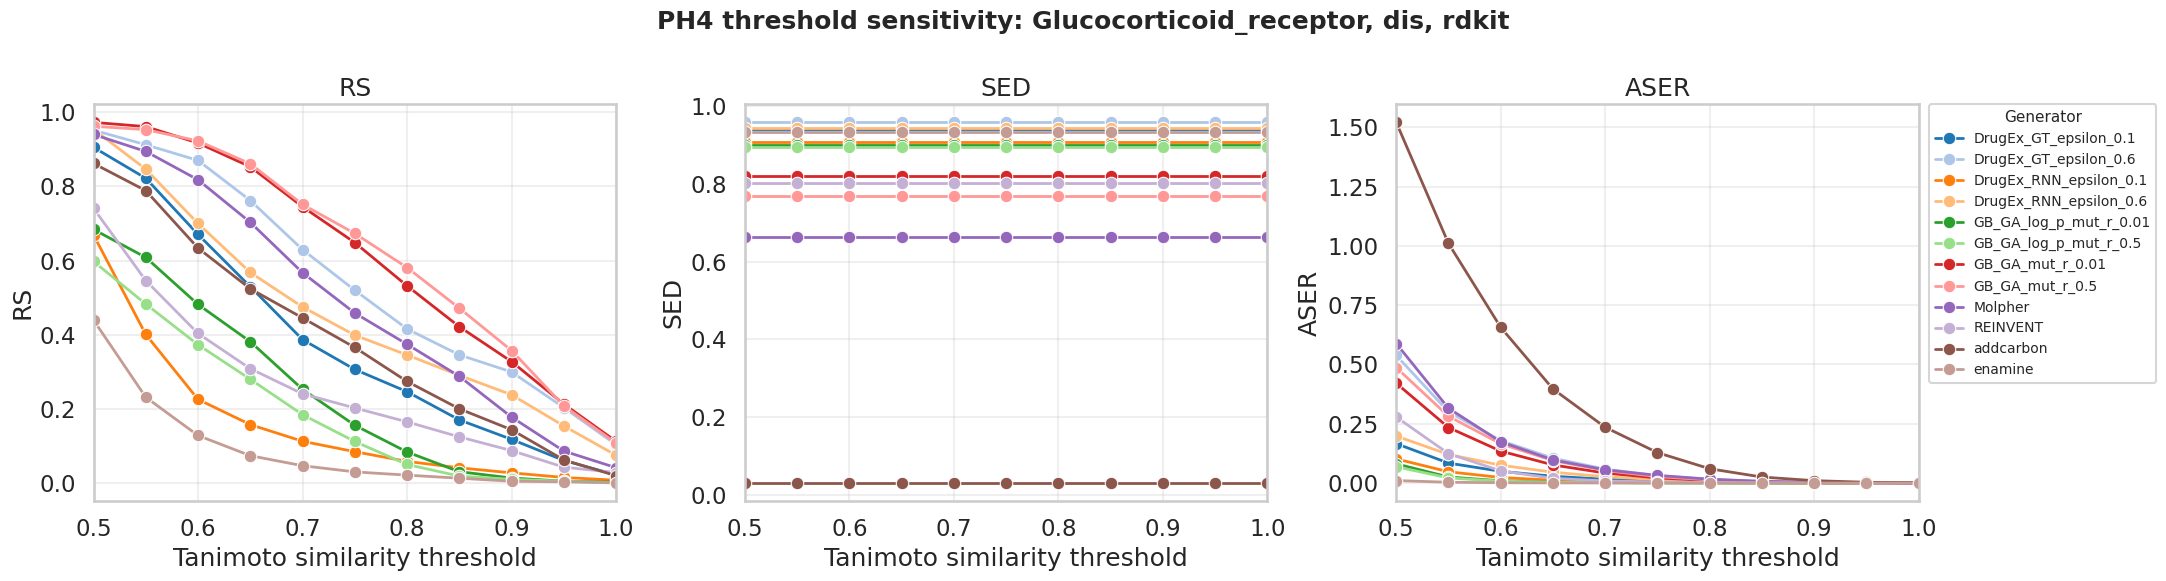

In [18]:
fig, axes = pts.plot_threshold_curves(
    threshold_df,
    receptor="Glucocorticoid_receptor",
    split="dis",
    output_dir=OUTPUT_DIR,
    phfp="rdkit",
)


In [ ]:
# Generate all receptor/split figures
for receptor in sorted(threshold_df["receptor"].unique()):
    for split in ["dis", "sim"]:
        if not threshold_df[(threshold_df["receptor"] == receptor) & (threshold_df["split"] == split)].empty:
            fig, axes = pts.plot_threshold_curves(
                threshold_df,
                receptor=receptor,
                split=split,
                output_dir=OUTPUT_DIR,
                phfp="rdkit",
                save=True,
            )
            plt.close(fig)


## Optional: Average Trend Across Generators

This view summarizes the threshold behavior across generators using the mean and standard deviation for each metric.


In [20]:
for receptor in sorted(threshold_df["receptor"].unique()):
    for split in ["dis", "sim"]:
        if not threshold_df[(threshold_df["receptor"] == receptor) & (threshold_df["split"] == split)].empty:
            fig, axes = pts.plot_average_threshold_trend(
                threshold_df,
                receptor=receptor,
                split=split,
                output_dir=OUTPUT_DIR,
                phfp="rdkit",
                save=True,
            )
            plt.close(fig)


Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations/ph4_threshold_average_trend_Glucocorticoid_receptor_dis_rdkit.png
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations/ph4_threshold_average_trend_Glucocorticoid_receptor_dis_rdkit.svg
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations/ph4_threshold_average_trend_Glucocorticoid_receptor_sim_rdkit.png
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations/ph4_threshold_average_trend_Glucocorticoid_receptor_sim_rdkit.svg
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations/ph4_threshold_average_trend_Leukocyte_elastase_dis_rdkit.png
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations/ph4_threshold_average_trend_Leukocyte_elastase_dis_rdkit.svg
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4

## Combined Plot for All Receptors and Splits

This section creates one combined figure with four rows:

1. Glucocorticoid receptor, DIS
2. Glucocorticoid receptor, SIM
3. Leukocyte elastase, DIS
4. Leukocyte elastase, SIM

Each row contains the three metrics (`RS`, `SED`, `ASER`). The tidy long-format table used for plotting is also saved as CSV.


In [21]:
threshold_long_df = pts.make_threshold_long_table(threshold_df, phfp="rdkit")
long_csv = pts.save_threshold_long_table(threshold_long_df, OUTPUT_DIR)
display(threshold_long_df.head())


Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations/ph4_threshold_sensitivity_long_table.csv


,receptor,split,phfp,generator,generator_clean,threshold,metric,value,receptor_label,split_label,panel_label
0,Glucocorticoid_receptor,dis,rdkit,Molpher_250k,Molpher,0.50,ASER,0.588166,Glucocorticoid receptor,DIS,"receptor: Glucocorticoid receptor, split: DIS"
1,Glucocorticoid_receptor,dis,rdkit,Molpher_250k,Molpher,0.55,ASER,0.315279,Glucocorticoid receptor,DIS,"receptor: Glucocorticoid receptor, split: DIS"
2,Glucocorticoid_receptor,dis,rdkit,Molpher_250k,Molpher,0.60,ASER,0.174088,Glucocorticoid receptor,DIS,"receptor: Glucocorticoid receptor, split: DIS"
3,Glucocorticoid_receptor,dis,rdkit,Molpher_250k,Molpher,0.65,ASER,0.097453,Glucocorticoid receptor,DIS,"receptor: Glucocorticoid receptor, split: DIS"
4,Glucocorticoid_receptor,dis,rdkit,Molpher_250k,Molpher,0.70,ASER,0.055840,Glucocorticoid receptor,DIS,"receptor: Glucocorticoid receptor, split: DIS"


Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations/ph4_threshold_sensitivity_all_receptors_splits.png
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/thresholds_ph4/visualizations/ph4_threshold_sensitivity_all_receptors_splits.svg


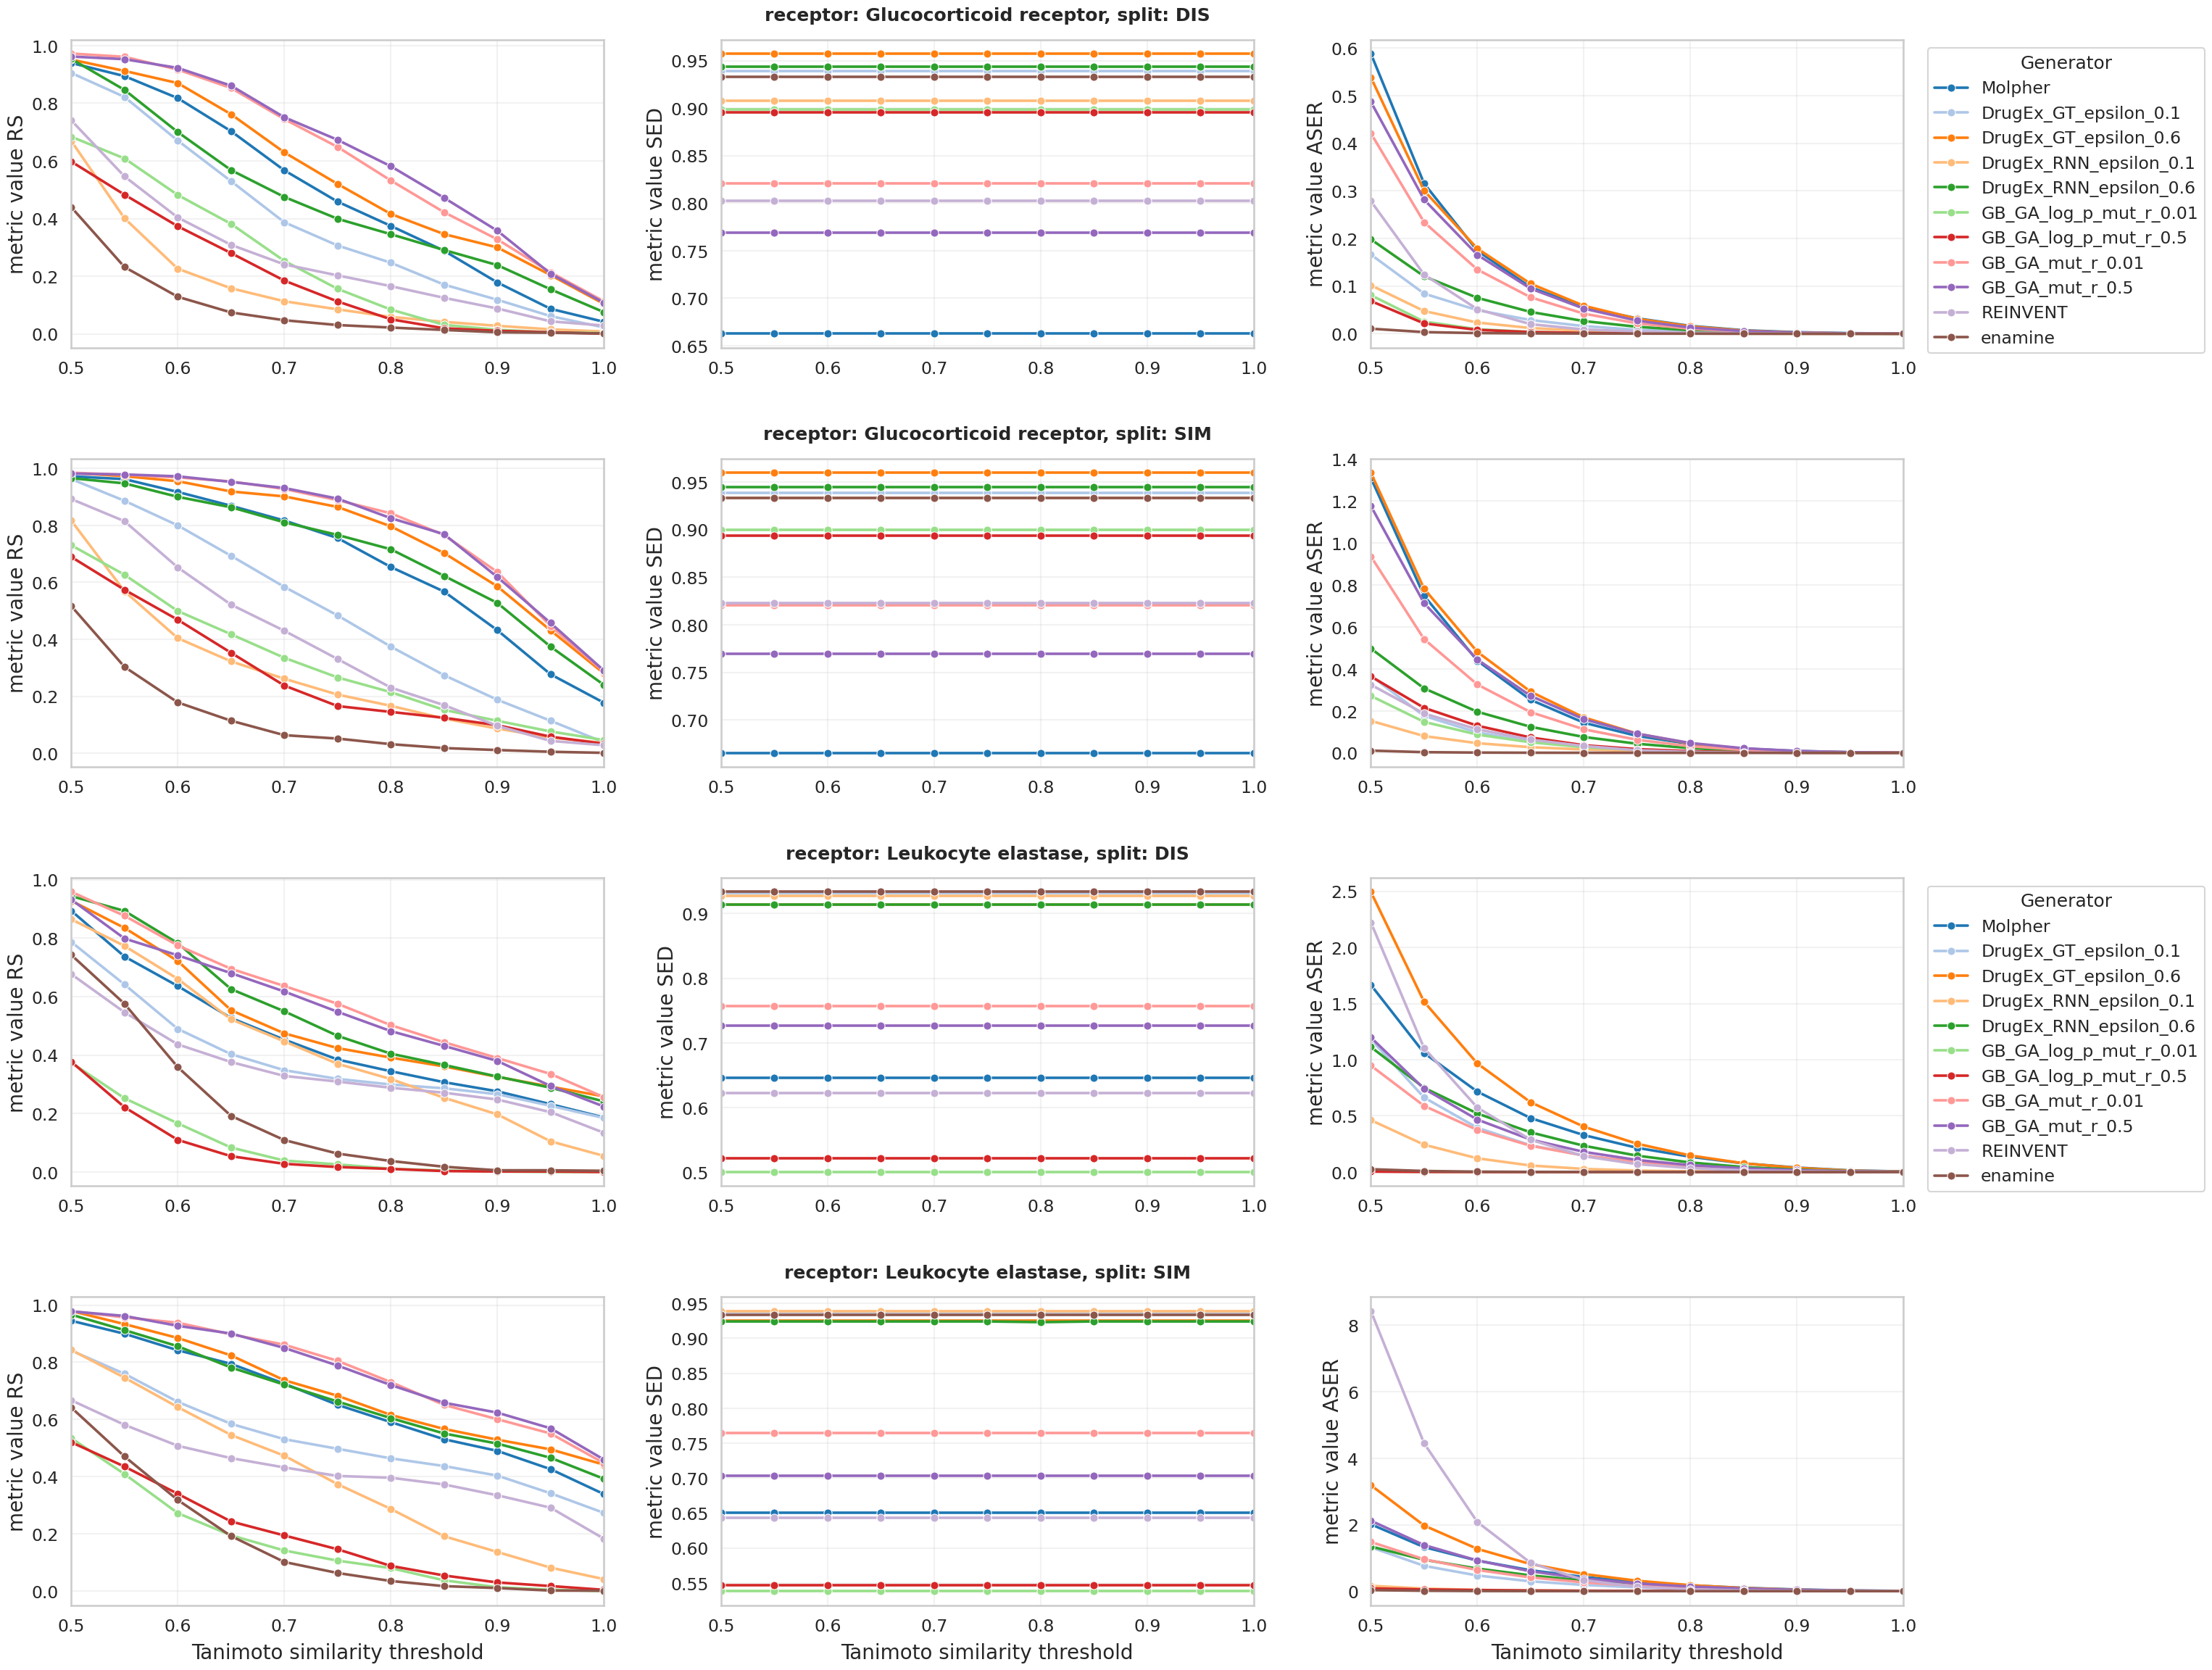

In [22]:
combined_fig, combined_axes = pts.plot_combined_threshold_sensitivity(
    threshold_long_df,
    output_dir=OUTPUT_DIR,
    save=True,
)
plt.show()
